# QC Exploration — Merck Bioassay Automation Sim
Loads the normalized results from a completed pipeline run and visualises:
1. Plate signal heatmap — spatial view of raw RFU across all 96 wells
2. Percent inhibition histogram — distribution of compound activity
3. Control separation — how well pos/neg controls are separated

### Normal run


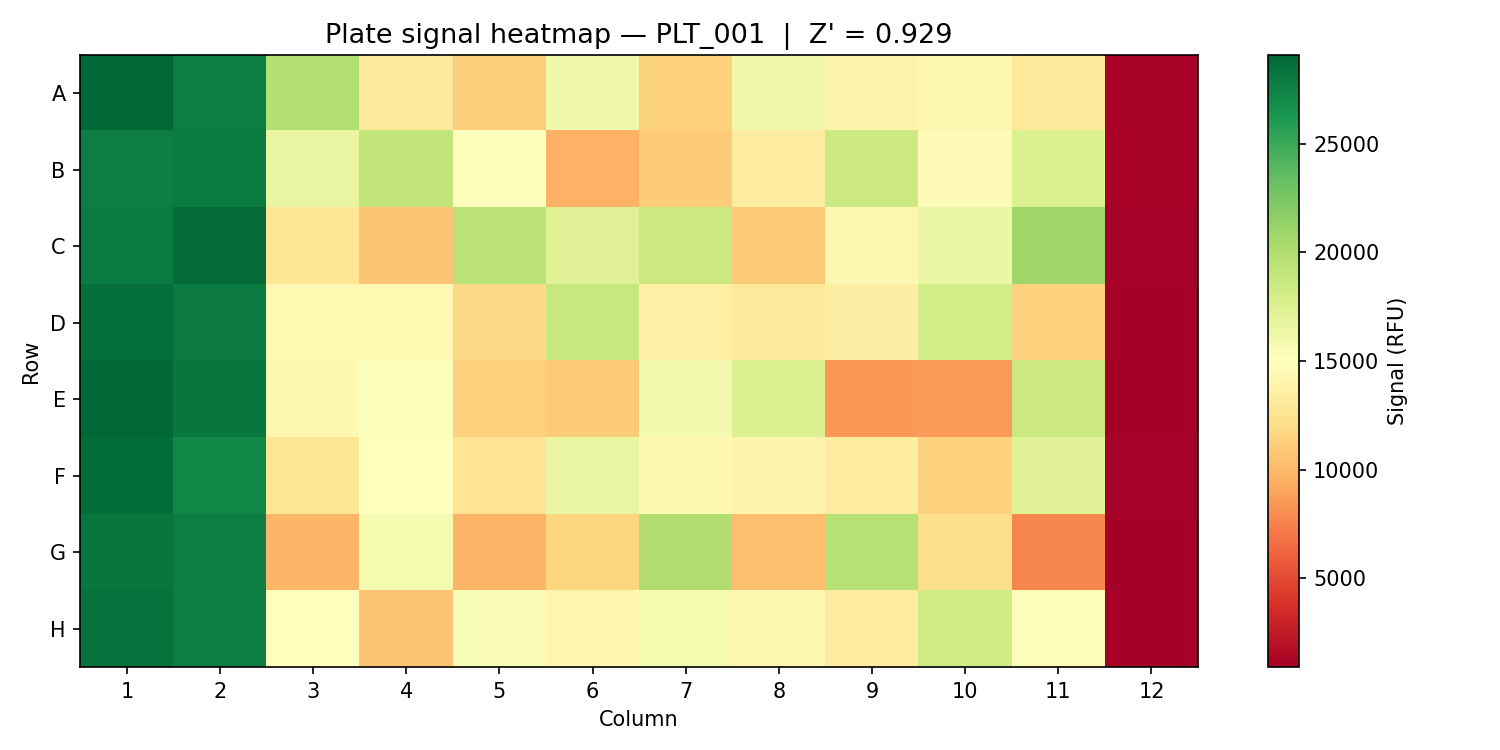

In [87]:
from IPython.display import Image
Image("../data/processed/normal_run_plate_heatmap_PLT_001.png", width=1120)

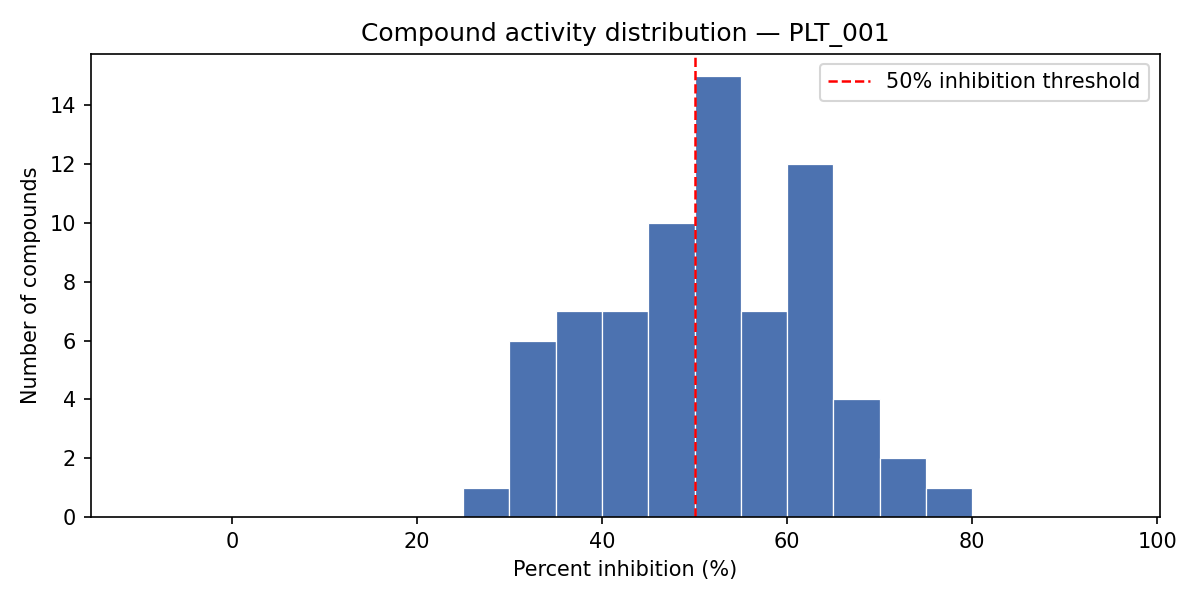

In [75]:
Image("../data/processed/normal_run_inhibition_histogram_PLT_001.png", width=946)

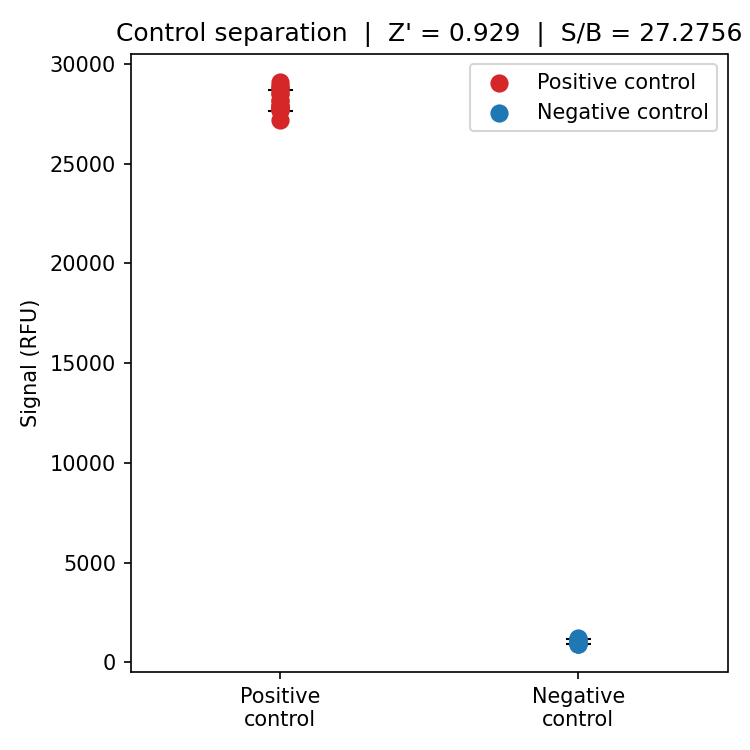

In [86]:
Image("../data/processed/normal_run_control_separation_PLT_001.png", width=596)

### Failed run

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json

plt.rcParams["figure.dpi"] = 120 #plt.rcParams is Matplotlib’s global settings dictionary. It controls default plot styles like font size, figure size, line widths, and resolution.
#dpi means dots per inch, which is basically image resolution.
plt.rcParams["font.family"] = "sans-serif"

In [77]:
normalized = pd.read_csv("../data/processed/normalized_results_PLT_001.csv")
with open("../data/processed/qc_report_PLT_001.json") as f:
    qc = json.load(f)

print(f"Plate:   {qc['plate_id']}")
print(f"Z'-factor: {qc['z_factor']}")
print(f"S/B ratio: {qc['signal_to_background']}")
print(f"Passed:  {qc['passed']}")
print(f"Wells loaded: {len(normalized)}")

Plate:   PLT_001
Z'-factor: -23.0848
S/B ratio: 1.095
Passed:  False
Wells loaded: 96


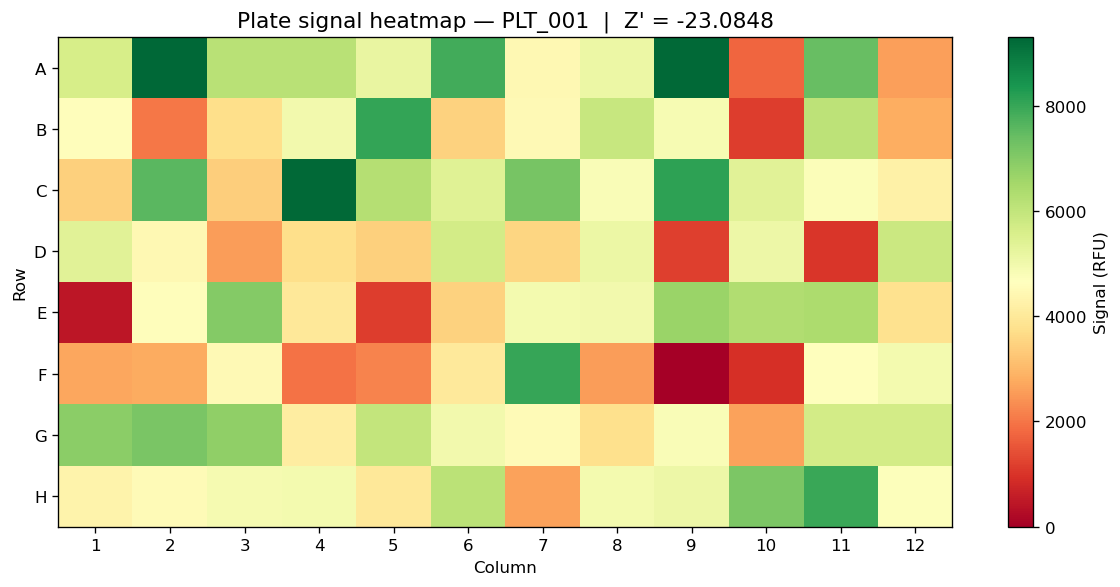

Saved → data/processed/plate_heatmap_PLT_001.png


In [78]:
# Build 8x12 signal matrix from well positions
rows = list("ABCDEFGH")
row_map = {r: i for i, r in enumerate(rows)} #creates a dictionary that maps row letters to row numbers: {'A': 0, 'B': 1, 'C': 2, ...} So row_map["C"] gives 2.

matrix = np.full((8, 12), np.nan) #makes a table of shape 8 rows by 12 columns filled with np.nan. np.nan means “not a number” and is used here as an empty placeholder.
for _, well in normalized.iterrows():
    r = row_map.get(well["row"]) #numeric row index taken from row_map. If well["row"] is "C", then r = 2.
    c = int(well["column"]) - 1 #olumn number converted to a zero-based index. Python array style: 0 to 11. int() converts text or a number-like value into an integer.
    if r is not None and 0 <= c < 12:
        matrix[r][c] = well["signal_rfu"]

fig, ax = plt.subplots(figsize=(10, 5)) #creates a figure and an axis. fig = the whole drawing canvas. ax = the actual plot area inside that canvas
im = ax.imshow(matrix, cmap="RdYlGn", aspect="auto") #imshow() means “show this matrix as an image.” Each cell in the matrix becomes a colored square. This is perfect for a heatmap.
#im is just a variable name, usually short for “image.” It stores the object returned by imshow().
#cmap means color map. RdYlGn = red-yellow-green palette: red for low, yellow in the middle, green for high.
#aspect="auto" lets Matplotlib choose a good shape for the plot instead of forcing square cells.
    
plt.colorbar(im, ax=ax, label="Signal (RFU)") #colorbar is the legend showing what colors mean numerically. Here it explains the RFU scale.

ax.set_xticks(range(12)) #places tick marks at x positions 0 through 11.
ax.set_xticklabels([str(i+1) for i in range(12)]) # turns numbers into text labels: i = 0 → str(1) → "1" So the x-axis labels become 1 to 12 instead of 0 to 11.
ax.set_yticks(range(8))
ax.set_yticklabels(list("ABCDEFGH"))
ax.set_title(f"Plate signal heatmap — {qc['plate_id']}  |  Z' = {qc['z_factor']}", 
             fontsize=13)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.tight_layout() #adjusts spacing automatically so labels, titles, and axes do not overlap or get cut off. It is a cleanup command. 
plt.savefig("../data/processed/plate_heatmap_PLT_001.png", dpi=150)
plt.show()
print("Saved → data/processed/plate_heatmap_PLT_001.png")

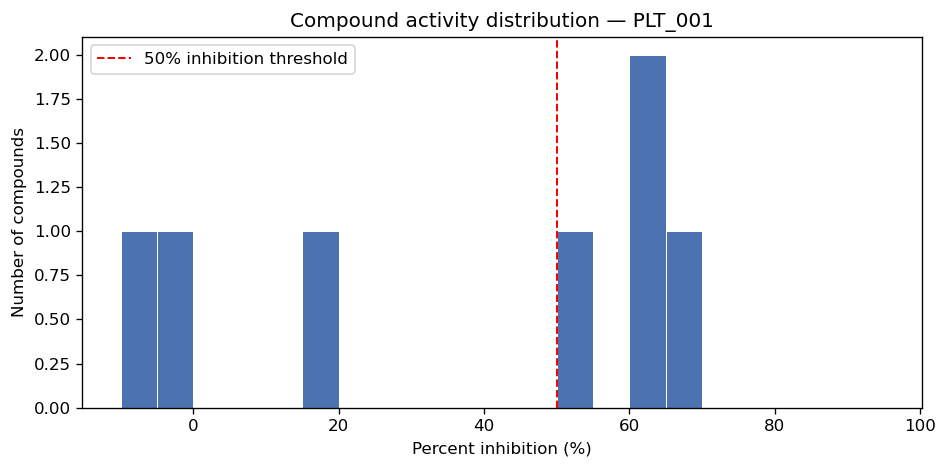

Compounds above 50% inhibition: 29 / 72


In [79]:
compounds = normalized[normalized["well_type"] == "compound"]["percent_inhibition"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(compounds, bins=np.arange(-10, 100, 5), color="#4C72B0", edgecolor="white", linewidth=0.6) #hist() = show distribution. 
#For percent inhibition, 0 and 100 are meaningful, so it can be better to define more intentional bins. makes bins every 5 units from -10 to 105.
ax.axvline(50, color="red", linestyle="--", linewidth=1.2, label="50% inhibition threshold") #draws a vertical line at x = 50.
ax.set_xlabel("Percent inhibition (%)")
ax.set_ylabel("Number of compounds")
ax.set_title(f"Compound activity distribution — {qc['plate_id']}")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/inhibition_histogram_PLT_001.png", dpi=150)
plt.show()
print(f"Compounds above 50% inhibition: {(compounds > 50).sum()} / {len(compounds)}")

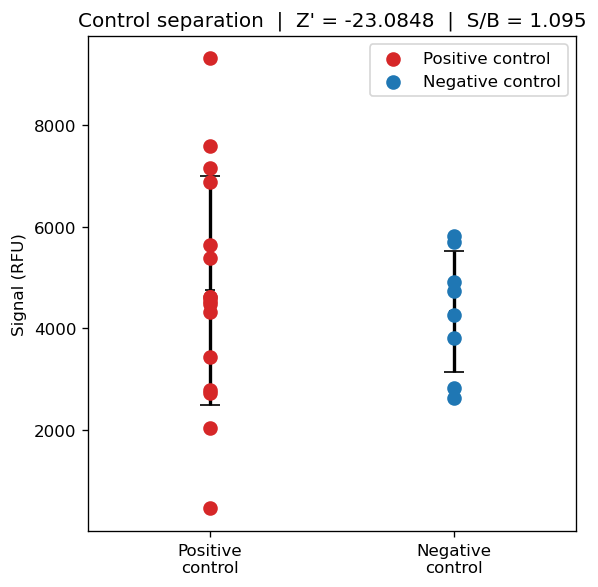

In [80]:
pos = normalized[normalized["well_type"] == "positive_control"]["signal_rfu"]
neg = normalized[normalized["well_type"] == "negative_control"]["signal_rfu"]

fig, ax = plt.subplots(figsize=(5, 5)) #reduces the figure width from (6, 4)
ax.scatter([1]*len(pos), pos, color="#d62728", s=60, label="Positive control", zorder=3) #makes a list of 1s, one for each positive control point. 
#If len(pos) = 4, then: [1] * 4 -> [1, 1, 1, 1]. That means all positive control points are placed at x = 1.
#s means marker size. zorder controls drawing order. higher zorder means drawn on top. So zorder=3 helps the scatter points appear above other plot elements.
ax.scatter([2]*len(neg), neg, color="#1f77b4", s=60, label="Negative control", zorder=3) #all negative control points are placed at x = 2.
ax.set_xlim(0.5, 2.5) #make the x-axis tighter and brings the points visually closer and remove wasted empty space.
ax.errorbar([1], [pos.mean()], yerr=[pos.std()], fmt="k_", capsize=6, linewidth=2) #errorbar() = show mean and spread. [1] and [2] are x-axis coordinates. [1] = draw the mean for positive controls at x = 1.
#[pos.mean()]: The y-value is the average signal for positive controls.
#yerr=[pos.std()] gives the error bar height. Here it uses one standard deviation above and below the mean.
#fmt="k_" is the format style: k = black. _ = horizontal line mark.
#capsize=6 adds little end caps to the error bars, making them easier to see.
ax.errorbar([2], [neg.mean()], yerr=[neg.std()], fmt="k_", capsize=6, linewidth=2)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Positive\ncontrol", "Negative\ncontrol"])
ax.set_ylabel("Signal (RFU)")
ax.set_title(f"Control separation  |  Z' = {qc['z_factor']}  |  S/B = {qc['signal_to_background']}")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/control_separation_PLT_001.png", dpi=150)
plt.show()